# Keyhole problem with MIDL
 Run `MIDL` to discover dominant dimensionless groups.

In [14]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf

current_notebook_dir = os.getcwd()
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '..', '..'))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)

import midl
MIDL = midl.MIDL
calc_basis = midl.calc_basis


In [15]:
df = pd.read_csv('dataset_keyhole.csv')
df.describe()
output_list = ['e*']
input_list = ['etaP', 'Vs', 'rho', 'cp', 'Tl-T0', 'r0', 'alpha']
X_raw = np.array(df[input_list])
Y = np.array(df[output_list])
num_input = 1
variables = input_list

D_in = np.matrix('2  1 1  2 -3  2  0; \
                 -3 -1 0 -1  0 -2  0; \
                  1  0 0  0  1  0  0; \
                  0  0 0  0  0 -1  1')
# Rearrange D_in columns accordingly: move 3rd and 4th columns (index 2 and 3) to the end
cols = list(range(D_in.shape[1]))
new_order = cols[:2] + cols[4:7] + [2, 3] + cols[7:]  # assumes 9 columns total
D_in = D_in[:, new_order]
print("D_in matrix:\n", D_in)


D_in matrix:
 [[ 2  1 -3  2  0  1  2]
 [-3 -1  0 -2  0  0 -1]
 [ 1  0  1  0  0  0  0]
 [ 0  0  0 -1  1  0  0]]


In [16]:
# Compute basis and construct independent dimensionless groups Pi
basis, r = calc_basis(D_in)
print('Null space dimension:', D_in.shape[1] - r)
print('basis:\n', basis)

Pi = np.exp(np.log(X_raw) @ basis)

Pi = np.zeros((X_raw.shape[0], basis.shape[1]))

for i in range(X_raw.shape[0]):
    log_x = np.log(X_raw[i, :])
    Pi[i, :] = np.exp(log_x @ basis)

Null space dimension: 3
basis:
 [[-0.19472782 -0.19670688 -0.34326655]
 [-0.52140612  0.67143546  0.23470804]
 [ 0.19472782  0.19670688  0.34326655]
 [ 0.52073917  0.07944325 -0.01724121]
 [ 0.52073917  0.07944325 -0.01724121]
 [ 0.32534441  0.63361509 -0.14304093]
 [ 0.06411124 -0.24020134  0.82957403]]


In [17]:
# Run MIDL
model = MIDL(
    k_neighbors=6,
    de_maxiter=200,
    random_state=42,
)

result = model.fit(Pi_independent=Pi, pi_dependent=Y, threshold=3)
pi_hat = MIDL.compose_new_pi(Pi, result['W'])

print('\n=== MIDL Results ===')
print('MI scores:', result['mi_scores'])
print('dominant_q:', result['dominant_q'])
print('drop ratios I_i / I_(i+1):', result['drop_ratios'])

# Exponents in original variable space
alpha = basis @ result['W']
print('\n=== Recovered exponents in original variables ===')
print(alpha)


[Step 1] MI = 1.564189
[Step 2] MI = 0.505499
   ratio = 3.094
   >>> Early stopping triggered at step 2

=== MIDL Results ===
MI scores: [1.56418884]
dominant_q: 1
drop ratios I_i / I_(i+1): 3.0943440398347275

=== Recovered exponents in original variables ===
[[ 0.3977179 ]
 [-0.1966305 ]
 [-0.3977179 ]
 [-0.3756071 ]
 [-0.3756071 ]
 [-0.55012679]
 [-0.24530902]]


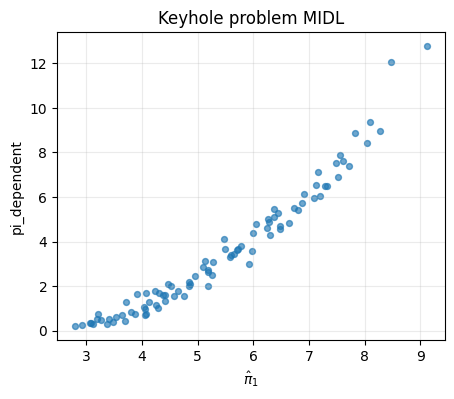

In [18]:
# Plot: 2D always, and extra 3D when dominant_q >= 2
if result['dominant_q'] >= 2:
    ax2d, ax3d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Keyhole problem MIDL',
        log_scale=True,
    )
else:
    ax2d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Keyhole problem MIDL',
        log_scale=False,
    )
plt.show()
